# SILVA Non-Euclidean Equilibrium

This lab derives the weighted-infinity certificate, reconstructs an exact
compact map, compares clean and perturbed equilibria, and evaluates the
analytic sensitivity bound. The mechanism follows NEMON [[77]](https://jseluis.github.io/silva-networks/paper/references/#ref-77).

<!-- silva-numbered-citations:start -->
**Numbered literature:** [[1]](https://jseluis.github.io/silva-networks/paper/references/#ref-1), [[4]](https://jseluis.github.io/silva-networks/paper/references/#ref-4), [[77]](https://jseluis.github.io/silva-networks/paper/references/#ref-77), [[81]](https://jseluis.github.io/silva-networks/paper/references/#ref-81). Each number opens the complete citation and its primary external source.
<!-- silva-numbered-citations:end -->


In [1]:
from pathlib import Path
import importlib.util
import subprocess
import sys

REPO_URL = "https://github.com/jseluis/silva-networks.git"

def find_local_silva_root():
    candidates = [Path.cwd(), Path("/content/silva-networks")]
    root = Path.cwd()
    while root != root.parent:
        candidates.append(root)
        root = root.parent
    for candidate in candidates:
        if (candidate / "src" / "silva_networks").exists():
            return candidate
    return None

root = find_local_silva_root()
if root is not None:
    sys.path.insert(0, str(root / "src"))
elif importlib.util.find_spec("silva_networks") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", f"git+{REPO_URL}"])
    root = Path.cwd()
else:
    root = Path.cwd()

In [2]:
import matplotlib.pyplot as plt
import torch

plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300})
torch.manual_seed(91)

from silva_networks import (
    SILVANonEuclideanEquilibrium,
    SolverConfig,
    make_non_euclidean_robustness_dataset,
)

## 1. Weighted Infinity Geometry

$$
\lVert z\rVert_{\infty,D}=\lVert Dz\rVert_\infty,
$$

$$
\mu_{\infty,D}(W)
=\max_i\left((DWD^{-1})_{ii}
+\sum_{j\ne i}|(DWD^{-1})_{ij}|\right).
$$

With free $A$ and target $m<1$,

$$
W=mI+D^{-1}AD-\operatorname{diag}(|A|\mathbf1)
$$

ensures $\mu_{\infty,D}(W)\leq m$.

In [3]:
data = make_non_euclidean_robustness_dataset(samples=24, seed=93)
model = SILVANonEuclideanEquilibrium(
    4,
    6,
    2,
    one_sided_bound=0.05,
    averaging=0.5,
    config=SolverConfig(
        solver="picard", max_iter=180, tol=1e-7, backward_mode="unrolled"
    ),
)
with torch.no_grad():
    model.operator.free_weight.copy_(data.free_weight)
    model.operator.log_metric.copy_(data.metric.log())
    model.source.weight.copy_(data.source)
    model.source.bias.copy_(data.bias)

nominal = model(data.inputs, return_result=True)
perturbed = model(data.perturbed_inputs, return_result=True)
state_error = torch.linalg.vector_norm(nominal.state - data.equilibrium)
assert nominal.one_sided_lipschitz <= 0.050001
assert state_error < 3e-4
print("one-sided certificate:", float(nominal.one_sided_lipschitz))
print("known-state error:", float(state_error))
print("recommended/used averaging:", float(model.operator.recommended_averaging()), float(nominal.averaging))

one-sided certificate: 0.050000011920928955
known-state error: 1.2534025017885142e-07
recommended/used averaging: 0.8446159362792969 0.5


## 2. Sensitivity Bound

For source matrix $U$,

$$
\operatorname{Lip}(x\mapsto z^\star(x))
\leq
\frac{\lVert DU\rVert_\infty}
{1-\mu_{\infty,D}(W)}.
$$

The compact perturbation is entrywise bounded. The empirical ratio should be
finite and can be compared with the returned analytic latent bound.

In [4]:
input_change = torch.linalg.vector_norm(
    data.perturbed_inputs - data.inputs, ord=float("inf"), dim=1
)
state_change = torch.linalg.vector_norm(
    perturbed.state - nominal.state, ord=float("inf"), dim=1
)
empirical = state_change / input_change
print("maximum empirical ratio:", float(empirical.max()))
print("analytic latent bound:", float(nominal.latent_input_lipschitz_bound))
assert torch.isfinite(empirical).all()

maximum empirical ratio: 0.8369634747505188
analytic latent bound: 1.2444936037063599


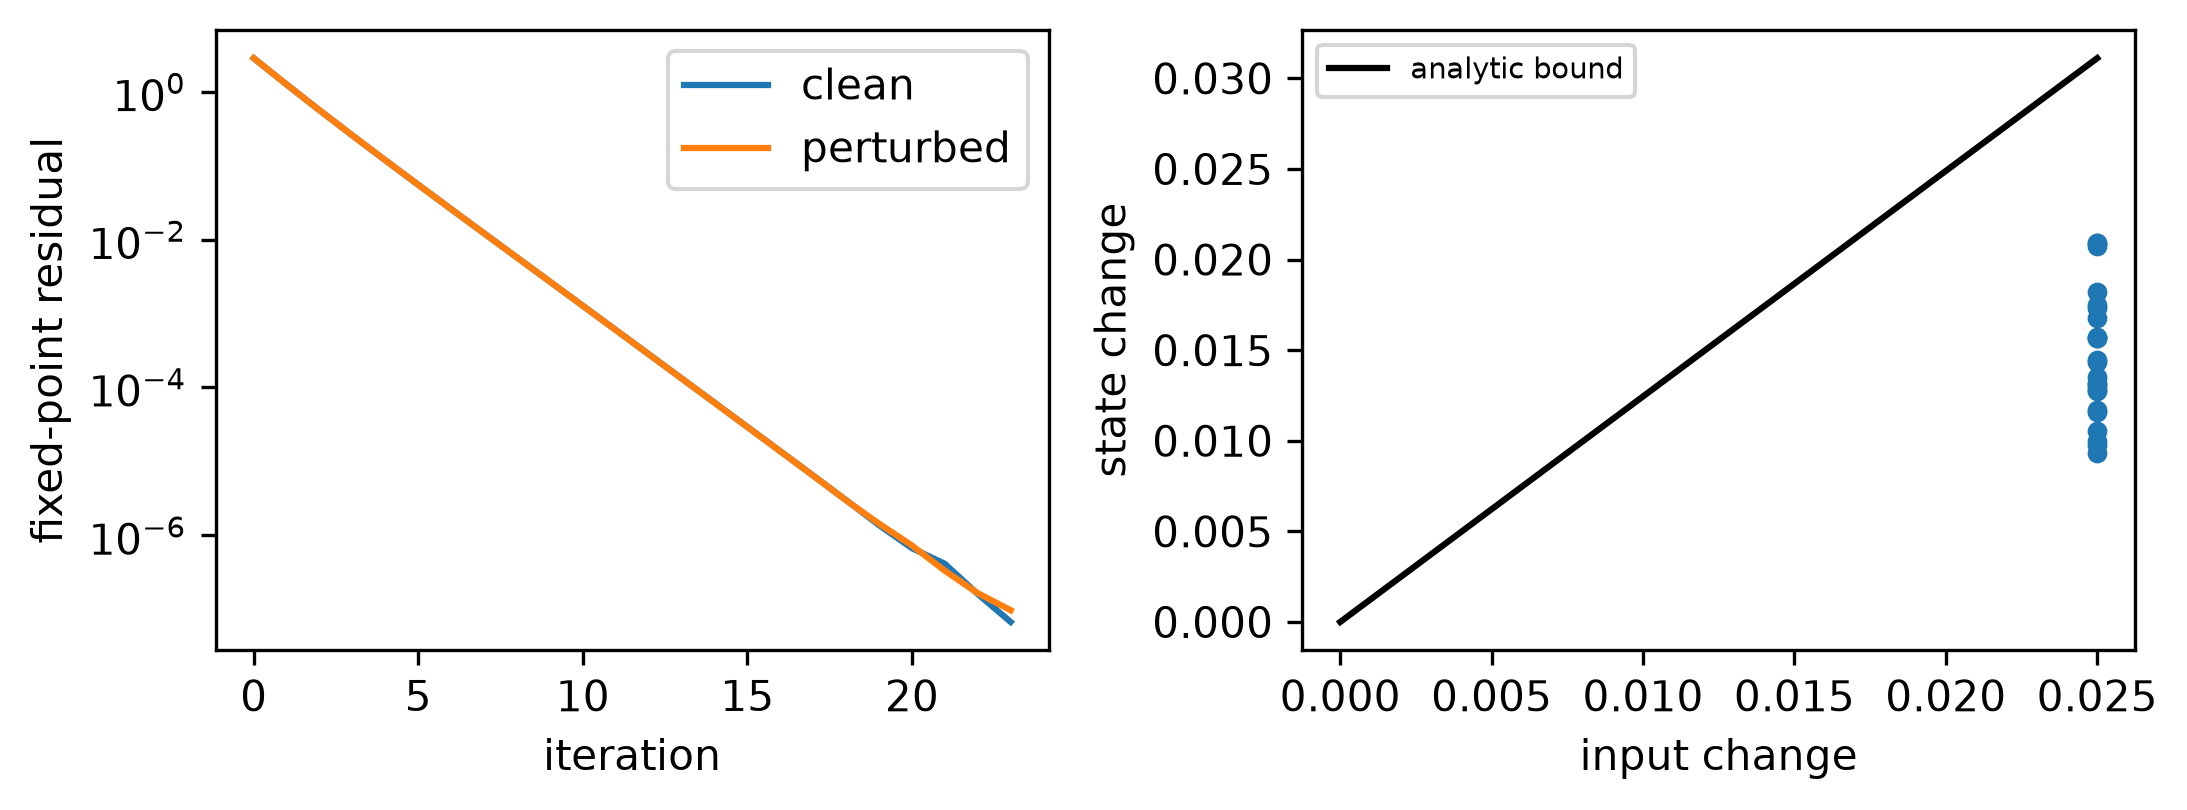

In [5]:
figure, axes = plt.subplots(1, 2, figsize=(7.4, 2.8))
axes[0].semilogy(nominal.solver_result.residuals, label="clean")
axes[0].semilogy(perturbed.solver_result.residuals, label="perturbed")
axes[0].set(xlabel="iteration", ylabel="fixed-point residual")
axes[0].legend()
axes[1].scatter(input_change.detach(), state_change.detach(), s=14)
bound_x = torch.linspace(0, float(input_change.max()), 30)
axes[1].plot(
    bound_x,
    bound_x * float(nominal.latent_input_lipschitz_bound.detach()),
    color="black",
    label="analytic bound",
)
axes[1].set(xlabel="input change", ylabel="state change")
axes[1].legend(fontsize=7)
figure.tight_layout()
plt.show()

## 3. Extension Boundary

The operator, metric, source, activation, averaging coefficient, and readout
are replaceable. A custom operator must expose its metric weights, weighted
matrix measure, and recommended averaging rule when the corresponding
certificate fields are expected in the result.

## 4. Real Images and the Sensitivity Contract

The weighted matrix measure constrains the latent fixed-point map; it does not
turn a ten-image run into a robustness benchmark. On source-indexed CIFAR-10
examples [[81]](https://jseluis.github.io/silva-networks/paper/references/#ref-81), we therefore report the clean loss, a bounded input
perturbation, the observed logit displacement, and the model's latent
input-Lipschitz bound as distinct quantities.

In [6]:
from urllib.request import urlretrieve
from silva_networks import load_source_snapshot

snapshot_path = root / "docs/assets/source-data/cifar10-balanced-10.pt"
if not snapshot_path.exists():
    snapshot_path = Path(".silva-source-data") / "cifar10-balanced-10.pt"
    snapshot_path.parent.mkdir(parents=True, exist_ok=True)
    snapshot_url = (
        "https://raw.githubusercontent.com/jseluis/silva-networks/main/"
        "docs/assets/source-data/cifar10-balanced-10.pt"
    )
    urlretrieve(snapshot_url, snapshot_path)

source_sample = load_source_snapshot(snapshot_path)
print("dataset:", source_sample.receipt.dataset)
print("source indices:", source_sample.receipt.selected_indices)
print("content SHA-256:", source_sample.receipt.content_sha256)
print("preprocessing:")
for step in source_sample.receipt.preprocessing:
    print(" -", step)

dataset: CIFAR10
source indices: (38683, 42292, 41716, 41053, 14490, 10657, 14443, 46034, 32019, 43901)
content SHA-256: 2c9f290825dc8690b27ca159d4681cda3db2198d35352f888bc3fbed23f21dfe
preprocessing:
 - deterministic class-balanced selection
 - scale image values to [0, 1]
 - bilinear resize to 16x16


In [7]:
from torch.nn import functional as F

real_images = source_sample.tensors["images"]
real_labels = source_sample.tensors["labels"].long()
real_vectors = real_images.flatten(1)
epsilon = 8.0 / 255.0
direction = torch.sign(torch.sin(torch.arange(real_vectors.numel()))).reshape_as(real_vectors)
perturbed_vectors = (real_vectors + epsilon * direction).clamp(0.0, 1.0)
real_model = SILVANonEuclideanEquilibrium(
    real_vectors.shape[1],
    24,
    10,
    one_sided_bound=0.05,
    config=SolverConfig(
        solver="picard",
        max_iter=120,
        tol=1e-6,
        backward_mode="unrolled",
        anderson_batch_dims=1,
    ),
)
clean = real_model(real_vectors, return_result=True)
perturbed_logits = real_model(perturbed_vectors)
clean_loss = F.cross_entropy(clean.output, real_labels)
clean_loss.backward()
per_sample_shift = torch.linalg.vector_norm(
    perturbed_logits.detach() - clean.output.detach(), dim=1
)
print("clean loss:", float(clean_loss.detach()))
print("weighted matrix measure:", float(clean.one_sided_lipschitz))
print("latent input-Lipschitz bound:", float(clean.latent_input_lipschitz_bound))
print("maximum observed logit shift:", float(per_sample_shift.max()))
assert clean.one_sided_lipschitz < 1

clean loss: 2.311626672744751
weighted matrix measure: 0.05000019073486328
latent input-Lipschitz bound: 15.042439460754395
maximum observed logit shift: 0.01747940480709076


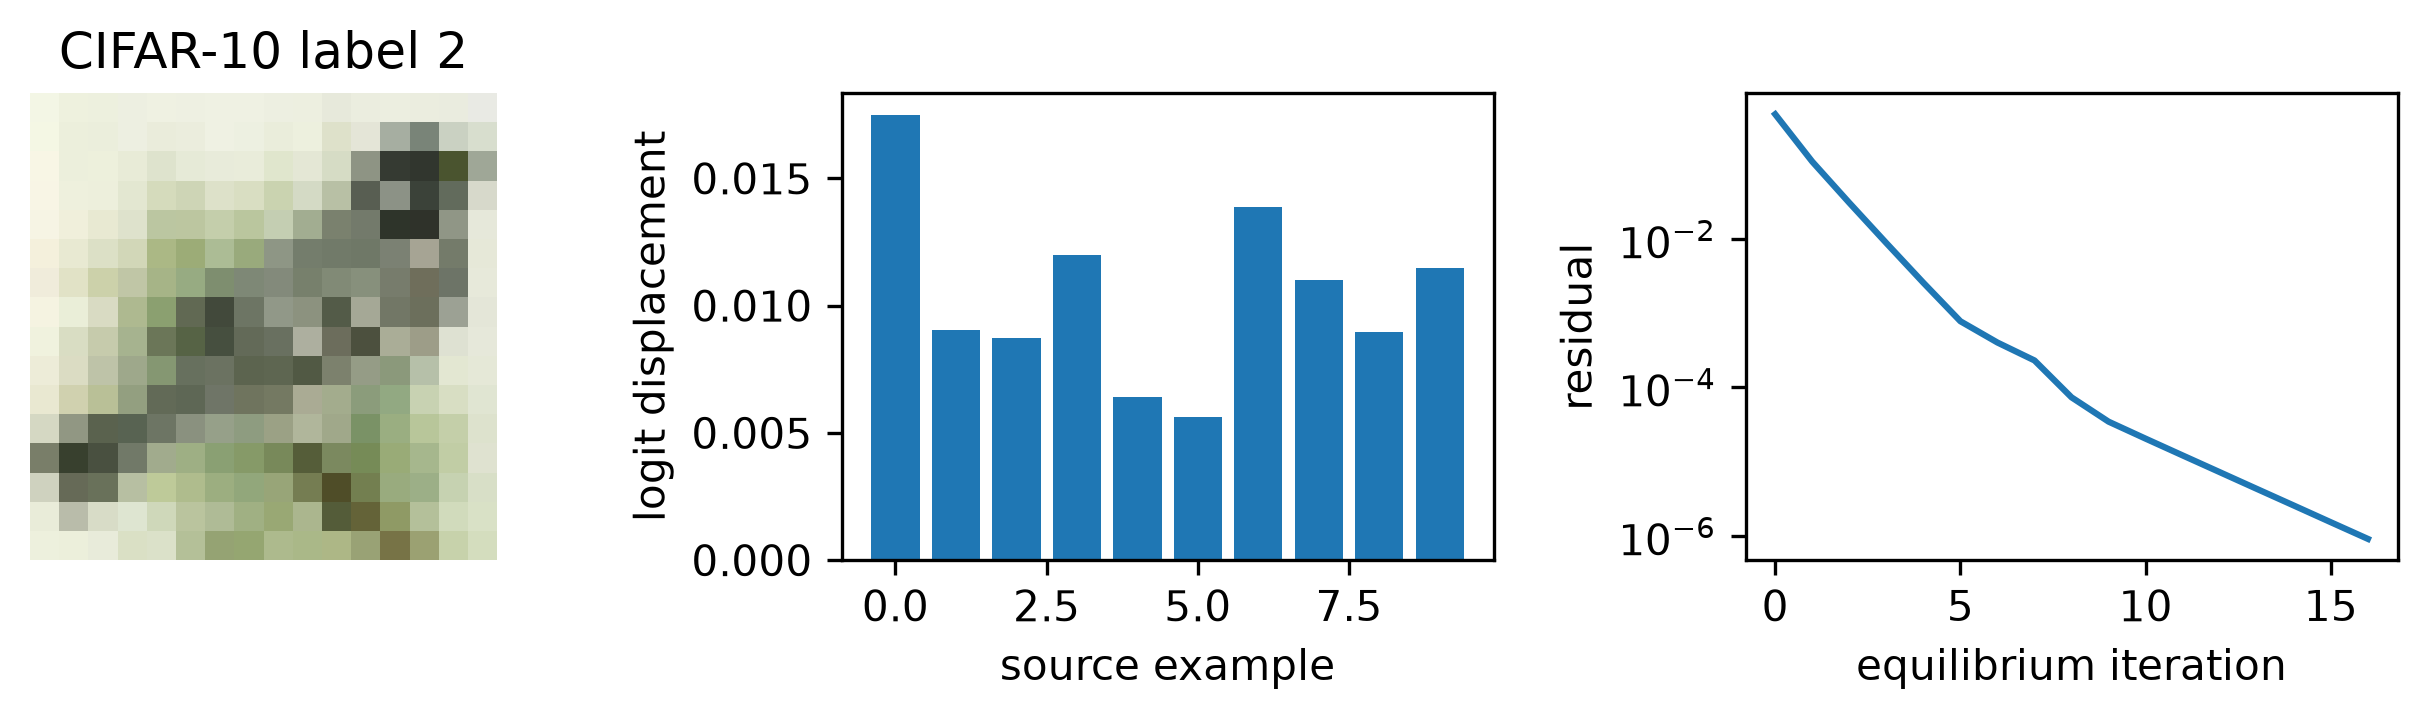

In [8]:
figure, axes = plt.subplots(1, 3, figsize=(8.5, 2.5))
axes[0].imshow(real_images[2].permute(1, 2, 0))
axes[0].set_title(f"CIFAR-10 label {int(real_labels[2])}")
axes[0].axis("off")
axes[1].bar(torch.arange(len(per_sample_shift)), per_sample_shift)
axes[1].set(xlabel="source example", ylabel="logit displacement")
axes[2].semilogy(clean.solver_result.residuals)
axes[2].set(xlabel="equilibrium iteration", ylabel="residual")
figure.tight_layout()
plt.show()

## Source-Scale Reproduction Contract

The compact run above verifies the defining mechanism, shapes, diagnostics,
and gradients. A published benchmark requires the source data, preprocessing,
architecture dimensions, optimization schedule, seeds, and evaluation budget.
The executable registry keeps those obligations beside the constructor.

In [9]:
from silva_networks import silva_reproduction_spec

spec = silva_reproduction_spec('silva_non_euclidean_equilibrium')
print("equation:", spec.equation)
print("datasets:", spec.datasets)
print("data sources:")
for value in spec.data_sources:
    print(" -", value)
print("source-scale steps:")
for index, value in enumerate(spec.source_scale_steps, start=1):
    print(f" {index}. {value}")
print("metrics:", spec.metrics)
print("preserved mechanisms:", spec.preserved_mechanisms)
print("SILVA extension points:", spec.silva_extensions)
print("benchmark obligations:", spec.benchmark_requirements)
print("constructor:", spec.constructor_signature)

equation: z_star=phi(A z_star+B x+b); mu_infinity,D(A)<1
datasets: ('MNIST', 'CIFAR-10', 'compact weighted-infinity perturbation pairs')
data sources:
 - https://arxiv.org/abs/2106.03194
 - https://github.com/davydovalexander/Non-Euclidean_Mon_Op_Net
source-scale steps:
 1. Acquire one declared benchmark and reproduce clean and perturbed evaluation preprocessing.
 2. Match the weighted metric, one-sided matrix-measure target, averaging rule, architecture, and solver settings.
 3. Verify the compact certificate and empirical sensitivity, then report clean/robust task metrics, residuals, runtime, and memory.
metrics: ('clean and perturbed task metric', 'one-sided Lipschitz certificate', 'empirical sensitivity', 'fixed-point residual')
preserved mechanisms: ('weighted-infinity matrix-measure contraction certificate', 'diagonally weighted parameterization and averaged fixed-point iteration', 'input-output sensitivity bound in the learned non-Euclidean metric')
SILVA extension points: ('rep

## From 38 Silva Non Euclidean Equilibrium to a Custom SILVA Family

The construction in this notebook can be separated into the universal
conditioned-equilibrium contract

$$
z_0=I_\eta(x),\qquad
z^\star=T_\theta(z^\star,x),\qquad
\widehat y=Q_\psi(z^\star).
$$

For this topic:

| Part | Concrete interpretation |
| --- | --- |
| Equilibrium state | the tensor solved to equilibrium |
| Condition | the observed input or source tensor |
| Repeated computation | the state-preserving transition evaluated by the root solver |
| Required invariants | shape, device, dtype, finiteness, and differentiability |
| Replaceable components | initializer, source encoder, transition, readout, and solver |

The initializer and source path are evaluated outside or alongside the root
solve. Only the state-preserving transition is repeated. Replacing an internal
architecture does not change this equation, provided the transition still maps
the same state space into itself.


### Replace the Certified Operator and Robustness Geometry

```python
model = SILVANonEuclideanEquilibrium(
    in_dim=input_dim,
    state_dim=state_dim,
    out_dim=output_dim,
    operator=my_weighted_infinity_operator,
    source=my_source,
    activation=my_monotone_nonexpansive_activation,
    readout=my_readout,
    averaging=None,
    config=solver_config,
)
```

The operator supplies the weighted matrix measure, metric weights, diagonal
lower bound, and recommended averaging coefficient. A source-scale robustness
study must preserve the clean split, perturbation norm and radius, attack
configuration, Lipschitz regularizer, and both clean and perturbed metrics.


In [10]:
import torch as silva_extension_torch
from torch import nn as silva_extension_nn

from silva_networks import (
    SILVAConditionedEquilibrium,
    SILVAZeroInitializer,
    SolverConfig,
    validate_silva_transition,
)


class NotebookExtensionTransition(silva_extension_nn.Module):
    def __init__(self, condition_dim=2, state_dim=3):
        super().__init__()
        self.source = silva_extension_nn.Linear(condition_dim, state_dim)
        self.state_field = silva_extension_nn.Sequential(
            silva_extension_nn.Linear(state_dim, 2 * state_dim),
            silva_extension_nn.Tanh(),
            silva_extension_nn.Linear(2 * state_dim, state_dim),
        )

    def forward(self, state, condition):
        return silva_extension_torch.tanh(
            self.source(condition) + 0.15 * self.state_field(state)
        )


silva_extension_torch.manual_seed(610)
notebook_condition = silva_extension_torch.linspace(-1.0, 1.0, 8).reshape(4, 2)
notebook_state0 = silva_extension_torch.zeros(4, 3)
notebook_transition = NotebookExtensionTransition()

notebook_report = validate_silva_transition(
    notebook_transition,
    notebook_state0,
    notebook_condition,
)
assert notebook_report.valid

with silva_extension_torch.no_grad():
    notebook_reference_step = silva_extension_torch.tanh(
        notebook_transition.source(notebook_condition)
        + 0.15 * notebook_transition.state_field(notebook_state0)
    )
silva_extension_torch.testing.assert_close(
    notebook_transition(notebook_state0, notebook_condition),
    notebook_reference_step,
)

notebook_custom_model = SILVAConditionedEquilibrium(
    notebook_transition,
    SILVAZeroInitializer(3),
    readout=silva_extension_nn.Linear(3, 1),
    config=SolverConfig(
        solver="picard",
        max_iter=40,
        tol=1e-7,
        backward_mode="implicit",
        backward_solver="gmres",
        anderson_batch_dims=1,
    ),
)
notebook_custom_result = notebook_custom_model(
    notebook_condition,
    return_result=True,
)
assert notebook_custom_result.output.shape == (4, 1)
assert notebook_custom_result.solver_result.residual < 1e-5

notebook_custom_result.output.square().mean().backward()
assert all(
    parameter.grad is not None and silva_extension_torch.isfinite(parameter.grad).all()
    for parameter in notebook_custom_model.parameters()
)
print("custom transition:", notebook_report)
print("equilibrium residual:", notebook_custom_result.solver_result.residual)


custom transition: SILVATransitionReport(state_shape=(4, 3), output_shape=(4, 3), preserves_shape=True, preserves_device=True, preserves_dtype=True, finite=True, differentiable=True, parameter_count=54)
equilibrium residual: 5.960464477539063e-08


## Numerical Equivalence, Compact Reproduction, and Scale

Before training, compare one packaged transition with an independently written
update:

$$
e_{\mathrm{step}}
=\frac{\|T_\theta(z,x)-T_{\mathrm{ref}}(z,x)\|_2}
{\|T_{\mathrm{ref}}(z,x)\|_2+\varepsilon}.
$$

After solving, report the fixed-point residual separately:

$$
e_{\mathrm{fp}}
=\frac{\|T_\theta(z^\star,x)-z^\star\|_2}
{\|z^\star\|_2+\varepsilon}.
$$

For this notebook, a compact reproduction must declare and assert
**fixed-point residual and task error against a deterministic target**. A full experiment must additionally record the
source dataset version and split, preprocessing, architecture widths, solver
and optimizer schedules, random seeds, baseline configuration, checkpoints,
and every deviation from the cited protocol.

The principal scaling axes are **state width, batch size, and data volume**. Increase one axis at
a time, retain the compact deterministic case as a regression test, and record
task error, domain-specific residual, forward residual, backward linear
residual, memory use, and runtime independently.

### Extension Exercises

1. Replace one component from this notebook while preserving its state and
   domain invariants.
2. Write the replacement first as an independent reference function, then as
   a module, and assert one-step equivalence.
3. Compare two solver configurations on the identical trained transition.
4. Add a compact baseline and a predeclared metric threshold.
5. Create a full-scale configuration without weakening the compact tests.

The complete authoring protocol is documented in
[Extending SILVA](https://jseluis.github.io/silva-networks/learn/extending-silva/).


In [11]:
notebook_reproduction_record = {
    "notebook": '38_silva_non_euclidean_equilibrium.ipynb',
    "state": 'the tensor solved to equilibrium',
    "condition": 'the observed input or source tensor',
    "transition": 'the state-preserving transition evaluated by the root solver',
    "invariants": 'shape, device, dtype, finiteness, and differentiability',
    "compact_metric": 'fixed-point residual and task error against a deterministic target',
    "scale_axis": 'state width, batch size, and data volume',
}
assert all(notebook_reproduction_record.values())
notebook_reproduction_record


{'notebook': '38_silva_non_euclidean_equilibrium.ipynb',
 'state': 'the tensor solved to equilibrium',
 'condition': 'the observed input or source tensor',
 'transition': 'the state-preserving transition evaluated by the root solver',
 'invariants': 'shape, device, dtype, finiteness, and differentiability',
 'compact_metric': 'fixed-point residual and task error against a deterministic target',
 'scale_axis': 'state width, batch size, and data volume'}

## Worked Convergence and Sensitivity Study

The preceding example demonstrates one configured solve. This additional study
changes the **transition feedback factor** while keeping the source fixed, so solver effort and
implicit sensitivity can be read separately from task behavior. Locally, one
eigendirection of a nonlinear transition can be represented by

$$
z_{k+1} = \rho z_k + u,
\qquad 0 \leq \rho < 1.
$$

Its equilibrium is

$$
z^\star = \frac{u}{1-\rho}.
$$

Subtracting the fixed-point equation from the iteration gives the exact error
recursion

$$
e_{k+1} = \rho e_k,
\qquad
|e_k| = \rho^k |e_0|.
$$

For a requested absolute tolerance $\tau$, the idealized iteration estimate is

$$
k \geq
\frac{\log(\tau/|e_0|)}{\log \rho}.
$$

The same factor controls sensitivity. Differentiating the equilibrium with
respect to the source gives

$$
\frac{\partial z^\star}{\partial u}
=\frac{1}{1-\rho}.
$$

Thus a transition can remain contractive while becoming expensive and highly
sensitive as $\rho$ approaches one. The table and figure below measure this
effect rather than merely stating it. They provide a reference envelope for
the notebook's actual state, **the tensor solved to equilibrium**, and its repeated map,
**the state-preserving transition evaluated by the root solver**. The scalar study does not replace the domain model;
it supplies a result whose convergence rate and derivative are known exactly,
so the same reporting code can be trusted before it is applied to the larger
transition.


In [12]:
import math as silva_deepening_math
import torch as silva_deepening_torch

silva_deepening_rates = (0.20, 0.45, 0.70, 0.85)
silva_deepening_source = 0.35
silva_deepening_tolerance = 1e-8
silva_deepening_histories = {}
silva_deepening_rows = []

for silva_deepening_rho in silva_deepening_rates:
    silva_deepening_state = silva_deepening_torch.tensor(0.0)
    silva_deepening_exact = silva_deepening_source / (1.0 - silva_deepening_rho)
    silva_deepening_history = []
    for silva_deepening_iteration in range(1, 241):
        silva_deepening_next = (
            silva_deepening_rho * silva_deepening_state + silva_deepening_source
        )
        silva_deepening_residual = abs(
            float(silva_deepening_next - silva_deepening_state)
        )
        silva_deepening_history.append(silva_deepening_residual)
        silva_deepening_state = silva_deepening_next
        if silva_deepening_residual < silva_deepening_tolerance:
            break

    silva_deepening_u = silva_deepening_torch.tensor(
        silva_deepening_source, requires_grad=True
    )
    silva_deepening_solution = silva_deepening_u / (1.0 - silva_deepening_rho)
    silva_deepening_solution.backward()
    silva_deepening_expected_sensitivity = 1.0 / (1.0 - silva_deepening_rho)
    silva_deepening_gradient_error = abs(
        float(silva_deepening_u.grad) - silva_deepening_expected_sensitivity
    )
    silva_deepening_histories[silva_deepening_rho] = silva_deepening_history
    silva_deepening_rows.append(
        (
            silva_deepening_rho,
            silva_deepening_iteration,
            silva_deepening_history[-1],
            abs(float(silva_deepening_state) - silva_deepening_exact),
            float(silva_deepening_u.grad),
            silva_deepening_gradient_error,
        )
    )

print('transition feedback factor')
print("rho | iterations | final residual | exact-state error | sensitivity | gradient error")
for silva_deepening_row in silva_deepening_rows:
    print(
        f"{silva_deepening_row[0]:.2f} | {silva_deepening_row[1]:3d} | "
        f"{silva_deepening_row[2]:.3e} | {silva_deepening_row[3]:.3e} | "
        f"{silva_deepening_row[4]:.4f} | {silva_deepening_row[5]:.3e}"
    )

assert all(row[2] < silva_deepening_tolerance for row in silva_deepening_rows)
assert all(row[3] < 1e-6 for row in silva_deepening_rows)
assert all(row[5] < 1e-6 for row in silva_deepening_rows)


transition feedback factor
rho | iterations | final residual | exact-state error | sensitivity | gradient error
0.20 |  12 | 0.000e+00 | 5.551e-17 | 1.2500 | 0.000e+00
0.45 |  23 | 0.000e+00 | 1.084e-08 | 1.8182 | 6.502e-08
0.70 |  45 | 0.000e+00 | 1.589e-07 | 3.3333 | 7.947e-08
0.85 |  93 | 0.000e+00 | 5.563e-07 | 6.6667 | 1.589e-07


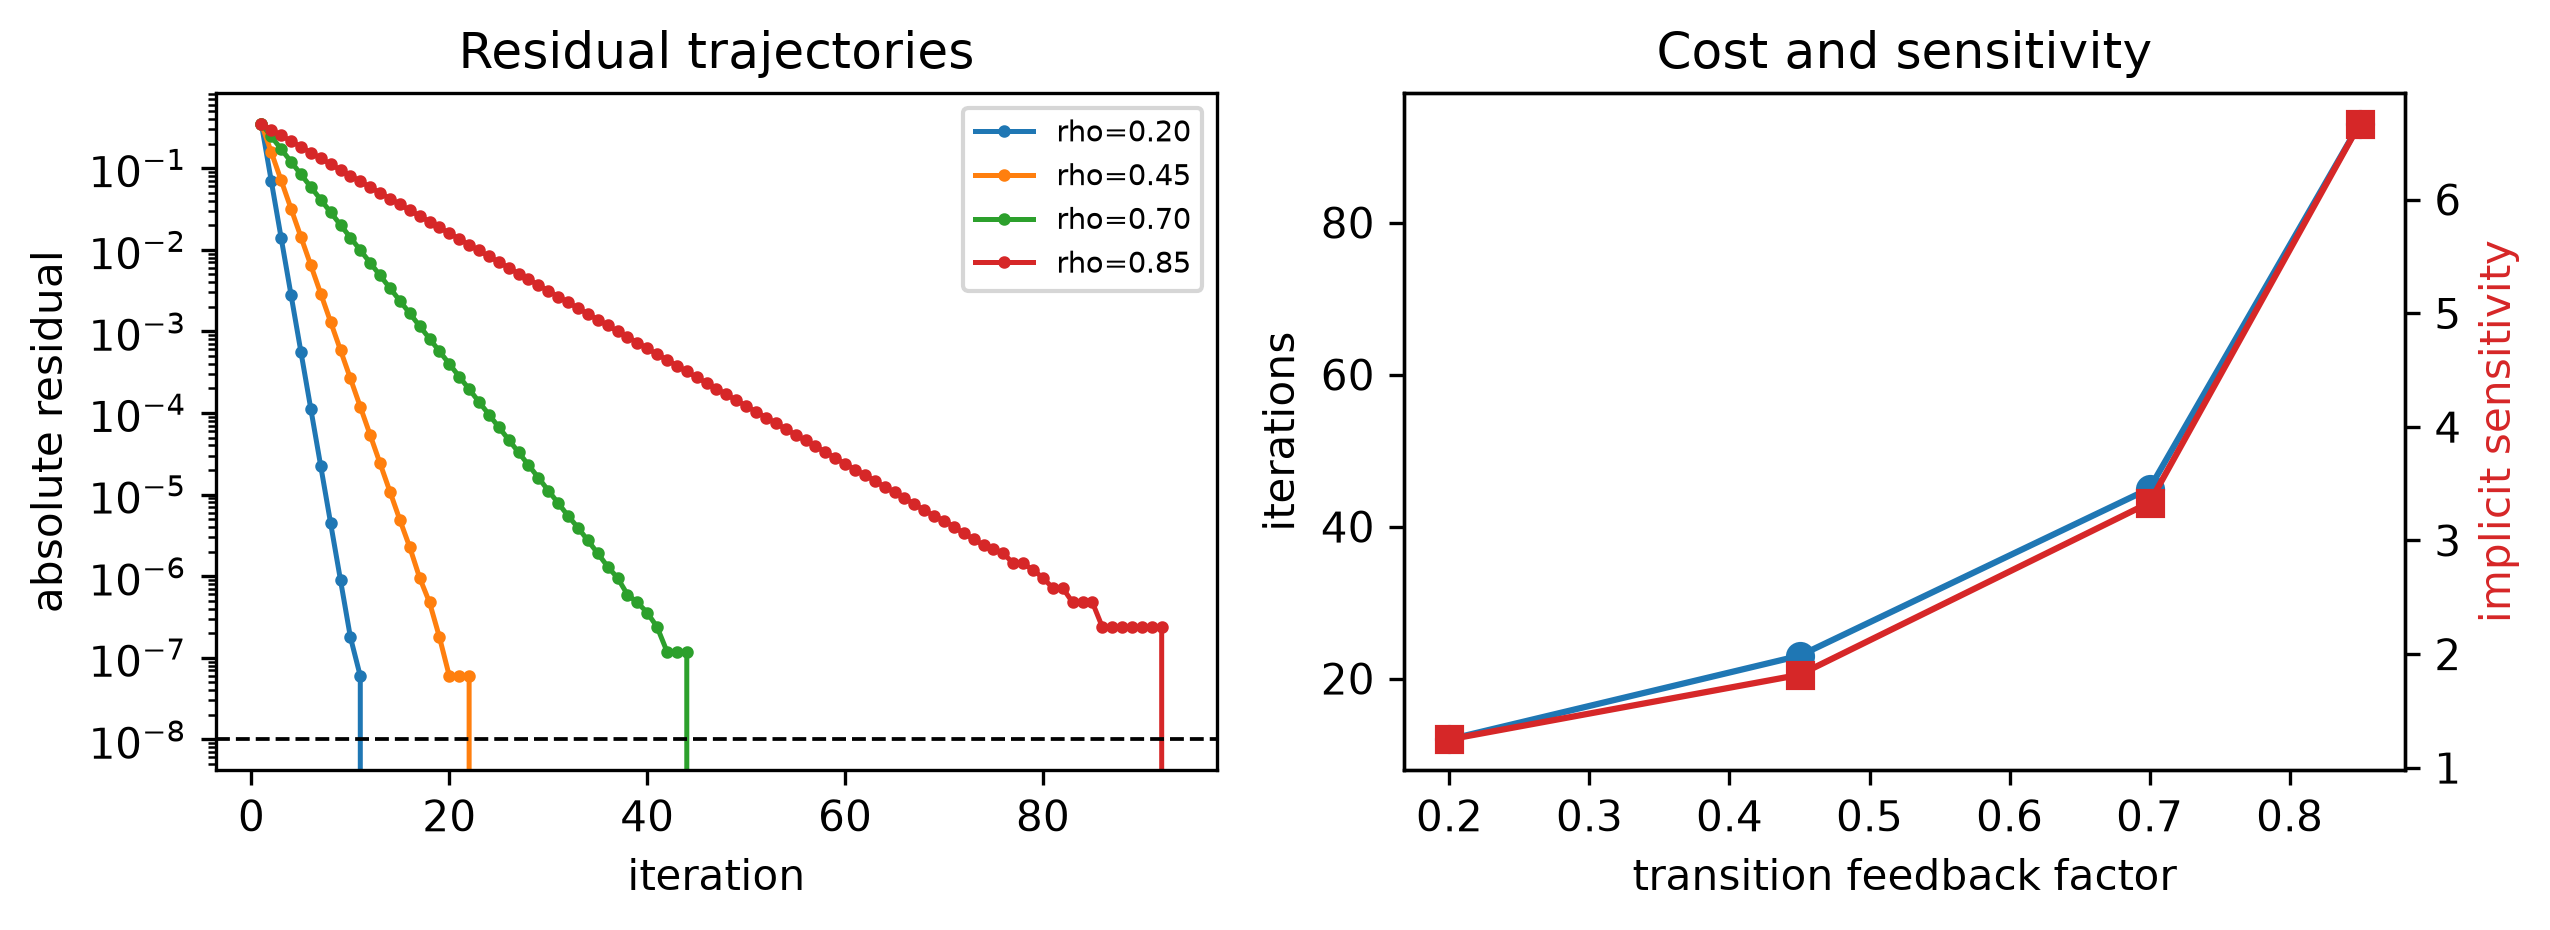

In [13]:
import matplotlib.pyplot as silva_deepening_plt

silva_deepening_plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300})
silva_deepening_figure, silva_deepening_axes = silva_deepening_plt.subplots(
    1, 2, figsize=(8.6, 3.2)
)
for silva_deepening_rho, silva_deepening_history in silva_deepening_histories.items():
    silva_deepening_axes[0].semilogy(
        range(1, len(silva_deepening_history) + 1),
        silva_deepening_history,
        marker="o",
        markersize=2,
        linewidth=1.2,
        label=f"rho={silva_deepening_rho:.2f}",
    )
silva_deepening_axes[0].axhline(
    silva_deepening_tolerance, color="black", linestyle="--", linewidth=0.9
)
silva_deepening_axes[0].set_xlabel("iteration")
silva_deepening_axes[0].set_ylabel("absolute residual")
silva_deepening_axes[0].set_title("Residual trajectories")
silva_deepening_axes[0].legend(fontsize=7)

silva_deepening_axes[1].plot(
    [row[0] for row in silva_deepening_rows],
    [row[1] for row in silva_deepening_rows],
    marker="o",
    label="iterations",
)
silva_deepening_sensitivity_axis = silva_deepening_axes[1].twinx()
silva_deepening_sensitivity_axis.plot(
    [row[0] for row in silva_deepening_rows],
    [row[4] for row in silva_deepening_rows],
    color="tab:red",
    marker="s",
    label="sensitivity",
)
silva_deepening_axes[1].set_xlabel('transition feedback factor')
silva_deepening_axes[1].set_ylabel("iterations")
silva_deepening_sensitivity_axis.set_ylabel("implicit sensitivity", color="tab:red")
silva_deepening_axes[1].set_title("Cost and sensitivity")
silva_deepening_figure.tight_layout()
silva_deepening_plt.show()


### Reading and Extending the Result

The measured residual curves become flatter as the transition feedback factor increases. The
iteration count and the exact sensitivity rise together, but they answer
different questions: iterations measure numerical work, while sensitivity
describes how strongly the equilibrium reacts to the source. The gradient-error
column verifies the differentiation path against the analytic derivative.

Apply the same separation to this notebook's full model:

| Report | Notebook-specific interpretation |
| --- | --- |
| Task evidence | fixed-point residual and task error against a deterministic target |
| Forward residual | Re-evaluate the complete transition at the returned state |
| Empirical rate | Compare consecutive residuals only after the transient regime |
| Backward residual | Record the linear-adjoint stopping value independently |
| Sensitivity | Perturb one declared source field while preserving all other inputs |
| Structural checks | shape, device, dtype, finiteness, and differentiability |
| Scale sweep | Change one of state width, batch size, and data volume at a time |

A richer experiment should now repeat the sweep with at least two forward
solvers, two tolerances, and multiple seeds. Keep model parameters and data
identical when comparing solvers. Then change one architecture or data-scale
axis, retain the compact analytic study as a regression test, and report task
quality, residuals, iterations, runtime, memory, gradient norms, and failed
convergence cases together.


## Where to Go Next

| Question | Page |
| --- | --- |
| How is the weighted-infinity certificate derived? | [Structured Equilibrium Families](https://jseluis.github.io/silva-networks/learn/structured-equilibrium-families/#non-euclidean-monotone-operator-network) |
| Which metric, averaging, and sensitivity APIs are public? | [Structured Equilibria API](https://jseluis.github.io/silva-networks/api/structured_equilibria/) |
| How is the compact perturbation problem generated? | [Structured Data API](https://jseluis.github.io/silva-networks/api/structured_data/) |
